In [ ]:
# run this once to install the required packages
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install statsmodels
%pip install scipy

# Current version: 2.9.2 (2024-06-03)
%pip install --upgrade "git+https://github.com/science64/DynaTMT-py-SB.git"

# Current version: 2.1.1 (2023-10-23)
%pip install --upgrade "git+https://github.com/science64/PBLMM.git"

In [1]:
# import the required packages
from datetime import date
import pandas as pd
import warnings
import DynaTMT_SB.DynaTMT as mePROD
import PBLMM

warnings.filterwarnings("ignore")

In [4]:
wd = "Example data/MS2_data" # you can define your folder here etc: C://Users/User/Data/fractionation/

nameOfStudy = "24h_CCCP_ISRIB_SB_import" # please define a name for your study

dataName = "20200724_SB_CCCP_ISRIB_Import_PSMs.txt" # please define the name of your data file (PSMs) here

conditions = ['Light', 'DMSO', 'DMSO', 'DMSO', 'CCCP', 'CCCP', 'CCCP', 'CCCP_ISRIB', 'CCCP_ISRIB', 'CCCP_ISRIB'] # define the conditions of TMT multiplexing here 

pairs = [['CCCP', 'DMSO'], ['CCCP_ISRIB', 'DMSO'], ['CCCP_ISRIB', 'CCCP']] # define the pairs of conditions you want to compare here. result will be log2(CCCP/DMSO)

In [ ]:
psms = pd.read_csv(f'{wd}/{dataName}', sep='\t', header=0) # TEXT or CSV file: you provide your .txt PSM or peptide file here.





In [7]:
psm_1 = psms.drop('Abundance: 131C', axis = True) # remove the booster channel if present

In [8]:
process = mePROD.PD_input(psm_1) # initiate your date here with PD_input class, if your data name is 'booster_removed'

filter_data = process.filter_PSMs(psm_1) # filter contamination, NA samples, shared peptides

IT_adjusted = process.IT_adjustment(filter_data) # IT adjusment helpful for MS2 samples

sumNorm = process.total_intensity_normalisation(IT_adjusted) # for total intenstiy normalization

heavy = process.extract_heavy(sumNorm) # extract heavy PSMs/peptides

light = process.extract_light(sumNorm) # extract light PSMs/peptides (OPTIONAL)

Calling function: filter_PSMs
Calling function: IT_adjustment
Calling function: total_intensity_normalisation
Calling function: extract_heavy
Extraction Done Extracted Heavy PSMs/Peptides: 65547
Calling function: extract_light
Extraction Done Extracted Light PSMs/Peptides: 98971


In [9]:

protein_data_heavy = process.protein_rollup(heavy, method='sum') # there are other methods as well, we are now using 'sum' 
                                                          # additionally you can use 'mean' and 'median' as well.
protein_data_heavy.head()


Calling function: protein_rollup


,Abundance: 126,Abundance: 127N,Abundance: 127C,Abundance: 128N,Abundance: 128C,Abundance: 129N,Abundance: 129C,Abundance: 130N,Abundance: 130C,Abundance: 131N
A0A0B4J2D5,5646.123143,7254.083363,6935.179379,7031.987883,5422.564465,5332.594778,5592.850066,5670.166109,6125.680924,6288.609174
A0A0B4J2F0,726.061770,944.494970,996.395436,937.778787,738.372093,742.799490,755.869395,1029.299880,855.222160,849.422934
A0A2R8Y4L2,50.721439,134.827520,184.724912,177.534536,145.727657,132.785228,126.990005,143.330906,421.605114,170.385182
A0A3B3IU46,562.977620,731.071976,838.894480,893.293412,744.278360,697.957348,681.335616,697.875632,645.096052,826.555210
A0AVT1,976.817514,1145.784639,1273.199284,1201.204711,1185.523852,1059.186541,967.529869,1251.262977,998.685219,1085.648105


In [10]:

protein_data_light = process.protein_rollup(light, method='sum') # there are other methods as well, we are now using 'sum' 
                                                          # additionally you can use 'mean' and 'median' as well.
protein_data_light.head()

Calling function: protein_rollup


,Abundance: 126,Abundance: 127N,Abundance: 127C,Abundance: 128N,Abundance: 128C,Abundance: 129N,Abundance: 129C,Abundance: 130N,Abundance: 130C,Abundance: 131N
A0A087X1C5,7954.774813,8294.328151,8501.564818,8147.045547,8575.517519,9593.290854,8585.694219,9467.422029,9368.149933,10777.786167
A0A096LP49,2030.218266,1568.732672,1387.161410,1361.956084,1828.561235,1728.280486,1592.267235,1785.035187,2377.331580,1506.420888
A0A0B4J2D5,74019.630473,76170.306599,70287.587569,77078.555036,86944.802609,90739.482305,96359.641070,90360.011693,94148.740971,90635.869591
A0A0B4J2F0,5251.856423,4597.460284,5165.813287,4532.123709,4265.480714,4296.175236,4405.144398,5705.509275,4340.556525,3563.528382
A0A0G2JMH6,1576.441322,1688.347403,1590.500660,2635.480738,1987.440927,1797.975149,1816.105940,1673.320294,3091.593384,1698.121783


In [15]:
protein_data_light.head()

,Accession,Abundance: 126,Abundance: 127N,Abundance: 127C,Abundance: 128N,Abundance: 128C,Abundance: 129N,Abundance: 129C,Abundance: 130N,Abundance: 130C,Abundance: 131N
0,A0A087X1C5,7954.774813,8294.328151,8501.564818,8147.045547,8575.517519,9593.290854,8585.694219,9467.422029,9368.149933,10777.786167
1,A0A096LP49,2030.218266,1568.732672,1387.161410,1361.956084,1828.561235,1728.280486,1592.267235,1785.035187,2377.331580,1506.420888
2,A0A0B4J2D5,74019.630473,76170.306599,70287.587569,77078.555036,86944.802609,90739.482305,96359.641070,90360.011693,94148.740971,90635.869591
3,A0A0B4J2F0,5251.856423,4597.460284,5165.813287,4532.123709,4265.480714,4296.175236,4405.144398,5705.509275,4340.556525,3563.528382
4,A0A0G2JMH6,1576.441322,1688.347403,1590.500660,2635.480738,1987.440927,1797.975149,1816.105940,1673.320294,3091.593384,1698.121783


In [12]:
protein_data_heavy.reset_index(inplace=True)
protein_data_heavy.rename(columns={'index': 'Accession'}, inplace=True)


protein_data_light.reset_index(inplace=True)
protein_data_light.rename(columns={'index': 'Accession'}, inplace=True)

In [ ]:
# Perform inner join on Accession to get matching proteins
merged = protein_data_heavy.merge(protein_data_light, on='Accession', suffixes=('_heavy', '_light'))

# Get abundance column names
abundance_cols = ['Abundance: 126', 'Abundance: 127N', 'Abundance: 127C',
                  'Abundance: 128N', 'Abundance: 128C', 'Abundance: 129N',
                  'Abundance: 129C', 'Abundance: 130N', 'Abundance: 130C',
                  'Abundance: 131N']

# Calculate Heavy/Light ratios for each abundance column
ratio_df = merged[['Accession']].copy()

for col in abundance_cols:
    heavy_col = f'{col}_heavy'
    light_col = f'{col}_light'
    ratio_col = f'H/L Ratio: {col.split(": ")[1]}'  # e.g., 'H/L Ratio: 126'
    
    # Calculate ratio, handling division by zero
    ratio_df[ratio_col] = merged[heavy_col] / merged[light_col]
    # Replace inf values (from division by zero) with NaN
    ratio_df[ratio_col].replace([float('inf'), -float('inf')], float('nan'), inplace=True)

print(f"Number of proteins in heavy: {len(protein_data_heavy)}")
print(f"Number of proteins in light: {len(protein_data_light)}")
print(f"Number of matching proteins: {len(ratio_df)}")
print("\nHeavy/Light Ratios:")
print(ratio_df.head(10))

# Optional: Save to CSV
ratio_df.to_excel('heavy_light_ratios.xlsx', index=False)

Number of proteins in heavy: 5308
Number of proteins in light: 6233
Number of matching proteins: 5120

Heavy/Light Ratios:
    Accession  H/L Ratio: 126  H/L Ratio: 127N  H/L Ratio: 127C  \
0  A0A0B4J2D5        0.076279         0.095235         0.098669   
1  A0A0B4J2F0        0.138249         0.205438         0.192883   
2  A0A3B3IU46        0.201878         0.279801         0.344377   
3      A0AVT1        0.089043         0.109631         0.118826   
4      A0FGR8        0.124297         0.196060         0.204541   
5      A0MZ66        0.499279         0.597862         0.602270   
6      A0PJW6        0.401769         0.383360         0.424193   
7      A1A4S6        0.470353         0.412461         0.581336   
8      A1L0T0        0.251138         0.315720         0.311493   
9      A1L188        0.293309         0.346485         0.367318   

   H/L Ratio: 128N  H/L Ratio: 128C  H/L Ratio: 129N  H/L Ratio: 129C  \
0         0.091231         0.062368         0.058768         0.058

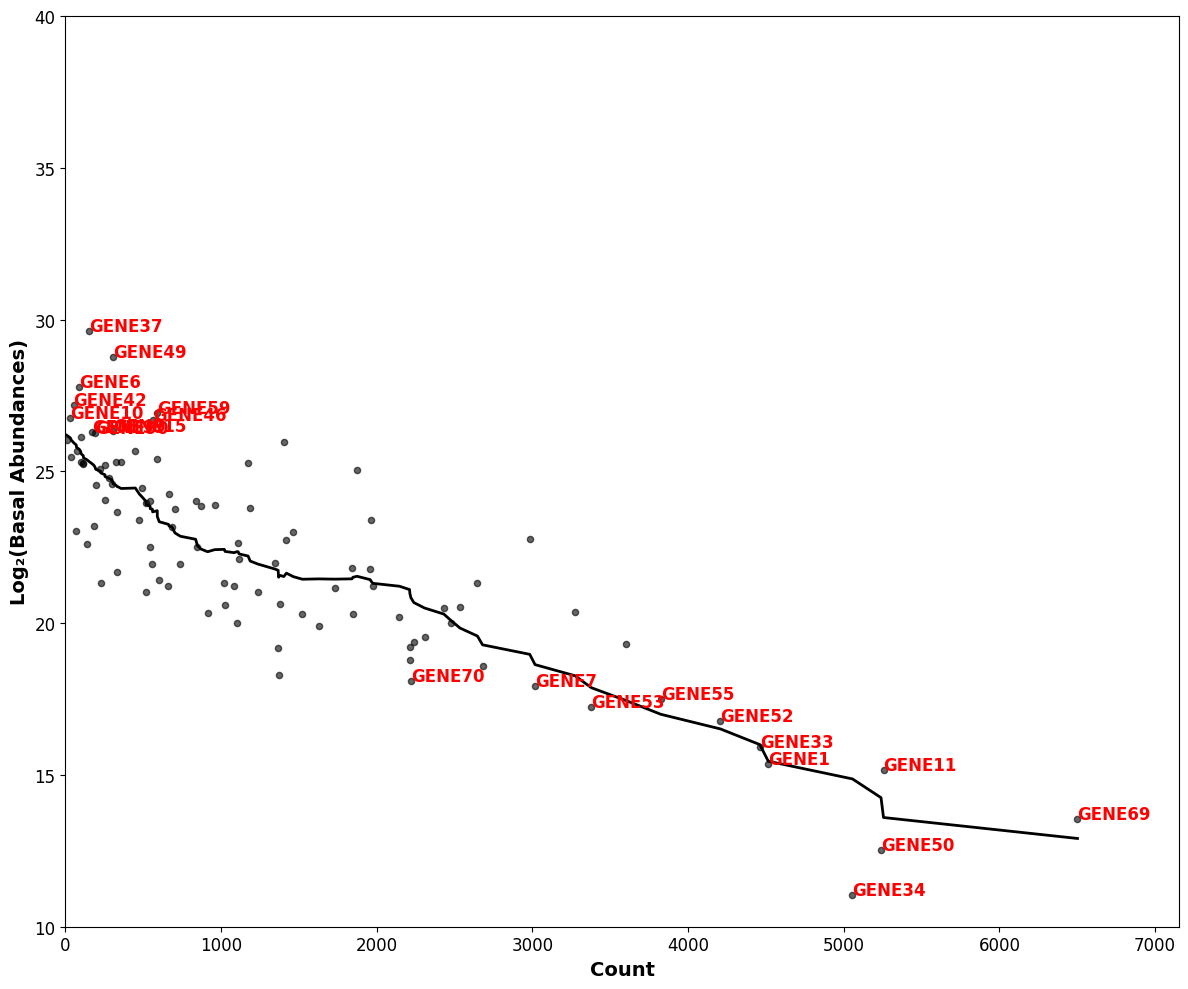

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from adjustText import adjust_text  # for non-overlapping labels

# Sample data
np.random.seed(42)
n_points = 100

# Generate mock data
count = np.random.exponential(1500, n_points)
log_abundance = 25 - 0.002 * count + np.random.normal(0, 2, n_points)

# Identify significant genes (example threshold)
significant = np.abs(log_abundance - np.mean(log_abundance)) > 4

# Gene names for significant points
gene_names = [f"GENE{i}" for i in range(n_points)]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot all points
ax.scatter(count[~significant], log_abundance[~significant], 
           c='black', s=20, alpha=0.6)
ax.scatter(count[significant], log_abundance[significant], 
           c='black', s=20, alpha=0.6)

# Fit smooth curve (LOESS-like using Savitzky-Golay filter)
sorted_idx = np.argsort(count)
sorted_count = count[sorted_idx]
sorted_abundance = log_abundance[sorted_idx]
smoothed = savgol_filter(sorted_abundance, window_length=51, polyorder=3)
ax.plot(sorted_count, smoothed, 'k-', linewidth=2)

# Add labels for significant genes
texts = []
for i in np.where(significant)[0]:
    texts.append(ax.text(count[i], log_abundance[i], gene_names[i], 
                        fontsize=12, color='red', fontweight='bold'))

# Adjust text to avoid overlaps (requires adjustText package)
# adjust_text(texts, arrowprops=dict(arrowstyle='-', color='red', lw=0.5))

# Formatting
ax.set_xlabel('Count', fontsize=14, fontweight='bold')
ax.set_ylabel('Log₂(Basal Abundances)', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(count) * 1.1)
ax.set_ylim(10, 40)
ax.tick_params(labelsize=12)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

In [ ]:
process = mePROD.PD_input(booster_removed) # initiate your date here with PD_input class, if your data name is 'booster_removed'

filter_data = process.filter_PSMs(booster_removed) # filter contamination, NA samples, shared peptides

IT_adjusted = process.IT_adjustment(filter_data) # IT adjusment helpful for MS2 samples

sumNorm = process.total_intensity_normalisation(IT_adjusted) # for total intenstiy normalization

heavy = process.extract_heavy(sumNorm) # extract heavy PSMs/peptides

light = process.extract_light(sumNorm) # extract light PSMs/peptides (OPTIONAL)

peptide_data = process.baseline_correction(heavy, threshold=15, i_baseline=0, random=True) # baseline correction of heavy PSMs/peptides

# PBLMM analysis ==> this is the main part of the statistical analysis based on peptide based linear mixed model (LMM)
hypothesis_testing = PBLMM.HypothesisTesting()
resultFinal = hypothesis_testing.peptide_based_lmm(peptide_data,conditions=conditions,pairs=pairs)
resultFinal.reset_index(inplace=True)
resultFinal.rename(columns={'index': 'Accession'}, inplace=True)

resultFinal.to_excel(f'{nameOfStudy}_mePROD_PBLMM_MS2_{date.today().strftime("%d.%m.%Y")}.xlsx', index=False, engine='openpyxl')

print('[#] COMPLETED: resultFinal: %s proteins x %s columns' % (resultFinal.shape[0], resultFinal.shape[1]))